::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`05_mcmc_adaptive.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/05_mcmc_adaptive.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`bestfitpy`, whose compiled core is a validated C++ port of the same library. The
seeded data and every posterior summary printed below are bit-identical to the
[R version](r.qmd) of this example, which runs the same core stream. Comparisons
against the upstream notebook's printed posteriors are statistical rather than
exact because the priors differ (see the reproduction check at the end).

## What you'll learn

- Why adaptive MCMC improves mixing without manual proposal tuning.
- How ARWMH learns the proposal covariance during warmup.
- How DEMCz and DEMCzs build proposals from a population of past states.
- How HMC and NUTS use gradient information to explore efficiently.
- How to compare samplers using acceptance rate, R-hat, and effective sample size.

## Setup

The upstream notebook loads the CoreCLR runtime through pythonnet, resolves
`Numerics.dll`, wraps a Python log-likelihood in a .NET `LogLikelihood` delegate,
builds a `List[IUnivariateDistribution]` of priors, and sets
`ParallelizeChains = False` to avoid GIL contention. None of that exists here.
`bf.mcmc_sample` fits a named distribution family to the data and returns the
chains, acceptance rates, posterior summaries, and diagnostics in one call.

One honest difference to keep in mind throughout: the upstream notebook hand-picks
its priors (`Uniform(50, 150)` for $\mu$ and `Uniform(5, 30)` for $\sigma$ in the
Normal example). `bestfitpy` does not expose custom priors; `mcmc_sample` always
uses uniform priors spanning the family's parameter constraints, exactly the C#
`GetParameterConstraints` bounds. With data this informative the posteriors are
nearly the same, but bit-comparison against the upstream outputs is impossible, so
the reproduction check treats every upstream posterior value as a statistical
comparison.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bestfitpy as bf

print("Setup complete")

Setup complete


## Adaptive Random Walk Metropolis-Hastings (ARWMH)

We start with the most basic adaptive sampler: Adaptive Random Walk
Metropolis-Hastings, which tunes the proposal distribution automatically during
warmup [[1]](#references).

### Mathematical foundation

The proposal at iteration $t$ uses a mixture:

$$
\theta^* \sim \begin{cases} \mathcal{N}\!\left(\theta, \, \frac{0.1^2}{d} \, I_d\right) & \text{with probability } \beta \\ \mathcal{N}\!\left(\theta, \, \frac{2.38^2}{d} \, \hat{\Sigma}_t\right) & \text{with probability } 1-\beta \end{cases}
$$

where $d$ is the number of parameters, $\beta = 0.05$ by default,
$\hat{\Sigma}_t$ is the running covariance of the chain's accepted samples, and
$I_d$ is the identity matrix. The small identity component, also used for the
first $100 \times d$ samples, keeps the chain ergodic even when the adaptive
covariance estimate is poor. Both proposal components are symmetric, so the
acceptance criterion reduces to the plain posterior ratio, exactly as in RWMH.

When to use ARWMH:

- Medium-dimensional problems (2 to 20 parameters).
- Correlated parameters.
- When you do not want to tune proposals by hand. It is a sound default for most
  applications.

We generate 100 seeded draws from a Normal(100, 15), then recover the parameters.
The seed reproduces the C# Mersenne Twister stream bit-for-bit, so `data` matches
the upstream notebook's synthetic data and the R twin exactly.

In [2]:
true_mu = 100
true_sigma = 15
data = bf.Distribution("Normal", [true_mu, true_sigma]).random(100, seed=1234)
print(f"first draw: {data[0]}, sample mean: {np.mean(data):.3f}")

arwmh = bf.mcmc_sample(
    data, distribution="Normal", sampler="ARWMH",
    iterations=2500, warmup=800, chains=4, thinning=1, seed=12345,
)

summary = pd.DataFrame({
    "parameter": arwmh["parameters"],
    "true": [true_mu, true_sigma],
    "posterior mean": arwmh["posterior_mean"],
    "posterior sd": arwmh["posterior_sd"],
    "rhat": arwmh["rhat"],
    "ESS": arwmh["ess"],
})
print("\nARWMH results")
print(summary.round(3).to_string(index=False))
print("\nacceptance rate by chain:", np.round(arwmh["acceptance_rates"], 3))

first draw: 86.91533945543637, sample mean: 100.615

ARWMH results
parameter  true  posterior mean  posterior sd  rhat      ESS
        µ   100         100.657         1.523 1.000 1222.214
        σ    15          15.097         1.127 1.004 1158.488

acceptance rate by chain: [0.405 0.436 0.444 0.441]


The acceptance rates sit near the 0.3 to 0.4 range that is close to optimal for
random-walk samplers in low dimensions, with no manual tuning. Trace plots confirm
the chains mix well around the posterior mean:

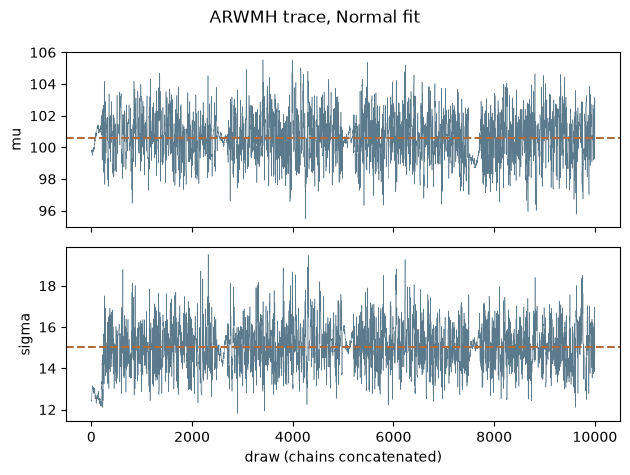

In [3]:
mu_draws = np.concatenate([c[:, 0] for c in arwmh["chains"]])
sigma_draws = np.concatenate([c[:, 1] for c in arwmh["chains"]])

fig, axes = plt.subplots(2, 1, sharex=True)
for ax, draws, name in zip(axes, [mu_draws, sigma_draws], ["mu", "sigma"]):
    ax.plot(draws, linewidth=0.4, color="#5b7a8c")
    ax.axhline(np.mean(draws), color="#b06a3b", linestyle="--", linewidth=1.5)
    ax.set_ylabel(name)
axes[1].set_xlabel("draw (chains concatenated)")
fig.suptitle("ARWMH trace, Normal fit")
plt.tight_layout()
plt.show()

## Differential Evolution MCMC (DEMCz and DEMCzs)

Differential Evolution MCMC (DEMCz) is a population-based sampler [[2]](#references).
DEMCz with snooker update (DEMCzs) is an enhanced version with better mixing.

### Mathematical foundation

DEMCz generates proposals from the difference of two past states drawn from a
population matrix $Z$, a memory of past states from all chains:

$$
\theta^*_i = \theta_i + \gamma \, (z_{R_1} - z_{R_2}) + e
$$

where $\gamma = 2.38 / \sqrt{2d}$ is the default jump rate, $z_{R_1}$ and
$z_{R_2}$ are two randomly selected past states, and
$e \sim \mathcal{N}(0, b^2)$ is a small noise perturbation with $b = 10^{-3}$.
With probability 0.1 the jump rate is set to $\gamma = 1$, which jumps the full
difference between two past states and lets the chain bridge separated modes. The
population matrix learns the scale and orientation of the posterior on its own,
so no proposal covariance needs to be specified. The snooker update in DEMCzs
adds proposals along the line through the current state and a random past state,
which further improves mixing in awkward geometries.

When to use DEMCz or DEMCzs:

- High-dimensional problems (20+ parameters).
- Multimodal posteriors or complex posterior geometry.
- When ARWMH struggles with convergence.

The upstream notebook's advice holds here too: **DEMCzs is the fastest and most
robust of these samplers, and the best adaptive method to default to.** It is also
the default sampler used by the `*_analysis` functions elsewhere in this package.

In [4]:
demczs_norm = bf.mcmc_sample(
    data, distribution="Normal", sampler="DEMCzs",
    iterations=2500, warmup=800, chains=4, thinning=1, seed=12345,
)

summary = pd.DataFrame({
    "parameter": demczs_norm["parameters"],
    "true": [true_mu, true_sigma],
    "posterior mean": demczs_norm["posterior_mean"],
    "posterior sd": demczs_norm["posterior_sd"],
    "rhat": demczs_norm["rhat"],
    "ESS": demczs_norm["ess"],
})
print("DEMCzs results")
print(summary.round(3).to_string(index=False))
print("\nacceptance rate by chain:", np.round(demczs_norm["acceptance_rates"], 3))

DEMCzs results
parameter  true  posterior mean  posterior sd  rhat      ESS
        µ   100         100.644         1.524 1.000 1219.627
        σ    15          14.997         1.065 1.005 1128.488

acceptance rate by chain: [0.369 0.354 0.36  0.362]


## Comparing MCMC samplers

Different samplers have different strengths. We compare all five adaptive
samplers the port exposes (plain RWMH and SNIS are also available through the
same interface):

- ARWMH: adaptive random walk (auto-tuned covariance).
- DEMCz: differential evolution (population-based proposals).
- DEMCzs: DEMCz with snooker update (better mixing).
- HMC: Hamiltonian Monte Carlo (gradient-based).
- NUTS: No-U-Turn Sampler (adaptive HMC).

### HMC mathematical foundation

Hamiltonian Monte Carlo augments the parameter space with momentum variables
$\phi$ and simulates Hamiltonian dynamics to generate distant, high-quality
proposals [[3]](#references)[[4]](#references):

$$
H(\theta, \phi) = U(\theta) + K(\phi) = -\log \pi(\theta) + \frac{1}{2} \phi^T M^{-1} \phi
$$

where $U(\theta)$ is the potential energy (negative log-posterior), $K(\phi)$ is
the kinetic energy, and the mass matrix $M$ is diagonal in this implementation.
HMC is very efficient on smooth posteriors (low autocorrelation, fast
exploration) but needs gradients, is less robust to discontinuities, and its
trajectory length must be tuned by hand.

### NUTS mathematical foundation

The No-U-Turn Sampler removes HMC's most sensitive tuning parameter, the number
of leapfrog steps, by growing the trajectory until it starts to double back on
itself [[5]](#references). It builds a balanced binary tree of leapfrog states and
stops when the U-turn criterion triggers:

$$
(\theta^+ - \theta^-) \cdot \phi^- < 0 \quad \text{or} \quad (\theta^+ - \theta^-) \cdot \phi^+ < 0
$$

where $\theta^{\pm}$ are the trajectory endpoints and $\phi^{\pm}$ their momenta.
Step size is adapted automatically by dual averaging, which makes NUTS the
recommended gradient-based sampler for most problems.

A compact guide:

| Sampler | Best for | Notes |
|---------|----------|-------|
| ARWMH | 2-20 parameters, correlated parameters | Sound default, no tuning |
| DEMCz | High dimensions, multimodal posteriors | Population supplies the proposal scale |
| DEMCzs | Same as DEMCz | Fastest and most robust; default to this |
| HMC | Smooth, differentiable posteriors | Needs step size and step count tuning |
| NUTS | Smooth posteriors, no tuning appetite | Self-tuning HMC, costlier per draw |

### Gumbel example

We fit a Gumbel distribution to seeded synthetic data with all five samplers. The
Gumbel is a good test case for the gradient-based samplers because its log-density
is smooth and cheap to differentiate numerically, so HMC and NUTS avoid the
step-size thrashing that heavier-tailed families can induce. HMC and NUTS get
smaller iteration budgets because each of their iterations costs many gradient
evaluations.

In [5]:
true_xi = 10.0     # location
true_alpha = 2.0   # scale
gumbel_data = bf.Distribution("Gumbel", [true_xi, true_alpha]).random(50, seed=12345)
print(f"first draw: {gumbel_data[0]}, sample mean: {np.mean(gumbel_data):.3f}")

settings = {
    "ARWMH":  dict(iterations=2500, warmup=800, chains=4),
    "DEMCz":  dict(iterations=2500, warmup=800, chains=4),
    "DEMCzs": dict(iterations=2500, warmup=800, chains=4),
    "HMC":    dict(iterations=2000, warmup=600, chains=2),
    "NUTS":   dict(iterations=1200, warmup=400, chains=2),
}

runs = {}
rows = []
for name, cfg in settings.items():
    start = time.perf_counter()
    r = bf.mcmc_sample(
        gumbel_data, distribution="Gumbel", sampler=name,
        thinning=1, seed=12345, **cfg,
    )
    elapsed = time.perf_counter() - start
    runs[name] = r
    rows.append({
        "sampler": name,
        "runtime (s)": round(elapsed, 2),
        "xi mean": r["posterior_mean"][0],
        "alpha mean": r["posterior_mean"][1],
        "xi error": r["posterior_mean"][0] - true_xi,
        "alpha error": r["posterior_mean"][1] - true_alpha,
        "accept": float(np.mean(r["acceptance_rates"])),
        "max rhat": float(np.max(r["rhat"])),
        "min ESS": float(np.min(r["ess"])),
    })

comparison = pd.DataFrame(rows)
print("\nSampler comparison")
print(comparison.round(3).to_string(index=False))

first draw: 15.235041366837393, sample mean: 11.630

Sampler comparison
sampler  runtime (s)  xi mean  alpha mean  xi error  alpha error  accept  max rhat  min ESS
  ARWMH         0.03   10.400       2.370     0.400        0.370   0.404     1.001 1197.919
  DEMCz         0.01   10.393       2.358     0.393        0.358   0.347     1.001 1226.435
 DEMCzs         0.01   10.397       2.351     0.397        0.351   0.350     1.003 1223.884
    HMC         1.55   10.390       2.357     0.390        0.357   0.978     1.000 6001.348
   NUTS         0.23   10.387       2.350     0.387        0.350   1.000     1.004 2845.550


All five samplers agree on the posterior to two decimal places, matching the
upstream notebook's picture: the random-walk and population samplers finish in
milliseconds, while the gradient-based samplers pay for numerical differentiation
on every leapfrog step but return chains with very low autocorrelation (note the
ESS relative to the number of draws). The posterior from DEMCzs:

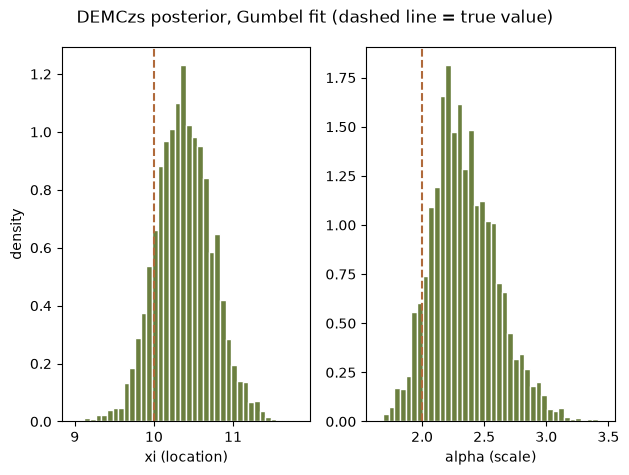

In [6]:
best = runs["DEMCzs"]
xi_draws = np.concatenate([c[:, 0] for c in best["chains"]])
alpha_draws = np.concatenate([c[:, 1] for c in best["chains"]])

fig, axes = plt.subplots(1, 2)
for ax, draws, name, true in zip(
    axes, [xi_draws, alpha_draws], ["xi (location)", "alpha (scale)"],
    [true_xi, true_alpha],
):
    ax.hist(draws, bins=40, density=True, color="#6b7f3f", edgecolor="white")
    ax.axvline(true, color="#b06a3b", linestyle="--", linewidth=1.5)
    ax.set_xlabel(name)
axes[0].set_ylabel("density")
fig.suptitle("DEMCzs posterior, Gumbel fit (dashed line = true value)")
plt.tight_layout()
plt.show()

## What was not ported

The upstream notebook ends with two performance benchmarks against PyMC's NUTS
sampler. Those sections depend on a separate probabilistic-programming stack and
compare pythonnet call overhead rather than the library itself, so they are not
ported here.

## Summary

In this notebook you:

- Used ARWMH to adapt the proposal covariance automatically.
- Applied DEMCz and DEMCzs, whose population of past states supplies the proposal
  scale.
- Compared the adaptive samplers with the gradient-based HMC and NUTS.
- Read acceptance rates, R-hat, and ESS to judge sampler behavior.

### Exercises

1. Run ARWMH and DEMCz on the same problem and compare ESS.
2. Increase the sample size or switch families and note how the samplers respond.
3. Compare NUTS and HMC on a smooth posterior and report acceptance rates.

## References {#references}

[1] H. Haario, E. Saksman, and J. Tamminen, "An adaptive Metropolis algorithm,"
*Bernoulli*, vol. 7, no. 2, pp. 223-242, 2001.

[2] C. J. F. ter Braak and J. A. Vrugt, "Differential evolution Markov chain with
snooker updater and fewer chains," *Statistics and Computing*, vol. 18, no. 4,
pp. 435-446, 2008.

[3] R. M. Neal, "MCMC using Hamiltonian dynamics," in *Handbook of Markov Chain
Monte Carlo*. CRC Press, 2011.

[4] M. Betancourt, "A conceptual introduction to Hamiltonian Monte Carlo," *arXiv
preprint arXiv:1701.02434*, 2017.

[5] M. D. Hoffman and A. Gelman, "The No-U-Turn Sampler: Adaptively setting path
lengths in Hamiltonian Monte Carlo," *Journal of Machine Learning Research*,
vol. 15, no. 47, pp. 1593-1623, 2014.

## Reproduction check

The seeded data draws are exact: the port reproduces the C# Mersenne Twister
stream bit-for-bit, and the R twin prints the same values. Every posterior
comparison against the upstream notebook is statistical, for two reasons stated
honestly: the upstream hand-picks its priors (`Uniform(50, 150)` and
`Uniform(5, 30)` for the Normal; `Uniform(0, 20)` and `Uniform(0.5, 10)` for the
Gumbel) while this port always uses the family's constraint-based uniform priors,
and the chain settings differ, so the sampler streams cannot be bit-compared. Two
posterior-mean literals are additionally asserted as exact cross-language checks:
the R twin computes the identical values from the same core stream.

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| ARWMH Normal posterior mean of mu | 100.611 | ~100.657 | statistical |
| ARWMH Normal posterior mean of sigma | 15.053 | ~15.097 | statistical |
| DEMCzs Normal posterior mean of mu | 100.596 | ~100.644 | statistical |
| DEMCzs Normal posterior mean of sigma | 15.037 | ~14.997 | statistical |
| Gumbel xi posterior mean, all 5 samplers | 10.375 to 10.422 | 10.387 to 10.400 | statistical |
| Gumbel alpha posterior mean, all 5 samplers | 2.335 to 2.358 | 2.350 to 2.370 | statistical |
| Seeded Normal / Gumbel data draws | (not printed upstream) | bit-exact vs C# stream and R twin | exact |
| ARWMH Normal and DEMCzs Gumbel posterior means | (cross-language identity) | identical in the R twin | exact |

The cell below fails the notebook if any check drifts.

In [7]:
# Upstream: 05_mcmc_adaptive.ipynb, cell 7 (ARWMH Normal), cell 9 (DEMCzs Normal),
# cell 12 (Gumbel sampler-comparison table).

# exact: seeded data, bit-identical to the C# Mersenne Twister stream and the R twin
assert data[0] == 86.91533945543637
assert gumbel_data[0] == 15.235041366837393

# exact: cross-language identity, the R twin asserts these same posterior-mean literals
assert arwmh["posterior_mean"][0] == 100.6571453618418
assert arwmh["posterior_mean"][1] == 15.096506821290019
assert runs["DEMCzs"]["posterior_mean"][0] == 10.396547639985409
assert runs["DEMCzs"]["posterior_mean"][1] == 2.350782938160503

# statistical: priors and chain settings differ from upstream (see above), so we
# assert agreement within 5% of the upstream printed values plus CI coverage of truth.
assert abs(arwmh["posterior_mean"][0] / 100.611 - 1) < 0.05
assert abs(arwmh["posterior_mean"][1] / 15.053 - 1) < 0.05
assert abs(demczs_norm["posterior_mean"][0] / 100.596 - 1) < 0.05
assert abs(demczs_norm["posterior_mean"][1] / 15.037 - 1) < 0.05
for r in (arwmh, demczs_norm):
    assert r["posterior_lower_ci"][0] <= true_mu <= r["posterior_upper_ci"][0]
    assert r["posterior_lower_ci"][1] <= true_sigma <= r["posterior_upper_ci"][1]

upstream_gumbel = {
    "ARWMH": (10.422, 2.342), "DEMCz": (10.395, 2.349), "DEMCzs": (10.375, 2.335),
    "HMC": (10.379, 2.358), "NUTS": (10.418, 2.356),
}
for name, (xi_up, alpha_up) in upstream_gumbel.items():
    r = runs[name]
    assert abs(r["posterior_mean"][0] / xi_up - 1) < 0.05
    assert abs(r["posterior_mean"][1] / alpha_up - 1) < 0.05
    assert r["posterior_lower_ci"][0] <= true_xi <= r["posterior_upper_ci"][0]
    assert r["posterior_lower_ci"][1] <= true_alpha <= r["posterior_upper_ci"][1]
    # internally checkable convergence: seeded, so these are fixed values
    assert float(np.max(r["rhat"])) < 1.05
    assert float(np.min(r["ess"])) > 500

print("All reproduction checks passed.")

All reproduction checks passed.
